In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
from modules import CHIP
# 初始化操作
chip=CHIP(local_ip="192.168.1.15",remote_ip="192.168.1.10",remote_port=7)               # 连接硬件平台
chip.set_device_cfg(deviceType=0,IsNew32=True)                                          # 配置器件设置：0表示ReRAM，1表示ECRAM
chip.adc.set_sample_times(adc_sample_times=4)                                           # 设置ADC采样次数
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=200,adc_last_gap=100)                     # ADC采样时序配置

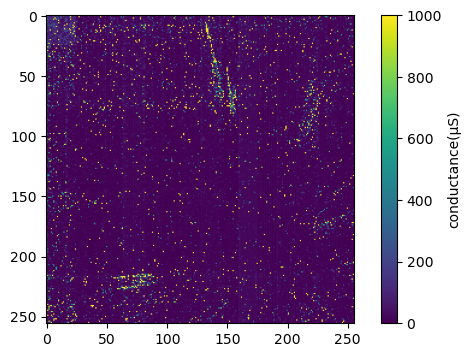

In [ ]:
selected_devices = np.ones((256,256),dtype=bool)                                        # 配置需要读取的器件，True表示被选中，False表示未选中
# 执行读操作，返回三个数据矩阵，ADC电压(V)、电导(μS)、电阻(kΩ)
voltage, conductance, resistance = chip.read4(crossbar=selected_devices,read_voltage=0.1,tg=5,gain=1,from_row=True,sub_base=False,
                                             split_type=1, row_type=0, col_type=0)
# 展示阵列器件的电导值
plt.figure(figsize=(7,4))
im = plt.imshow(conductance,norm=Normalize(vmin=0, vmax=1000))
cbar = plt.colorbar(im)
cbar.set_label("conductance(μS)")
plt.show()

In [ ]:
selected_devices = np.ones((256,256),dtype=bool)                                        # 配置需要读取的器件，True表示被选中，False表示未选中
tg = np.ones((256,256))                                                                 # 配置每个器件的栅极电压参数，每个器件栅极电压可以不一致
# 对选中器件执行SET操作
chip.write4(crossbar=selected_devices,write_voltage=1,tg=tg,pulse_width=1e-6,set_device=True,
            split_type=0, row_type=0, col_type=0)